In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
# yfinance is no longer needed since we are using local files

In [3]:
# Load and format Axis Bank data
axisbank = pd.read_csv('/content/AXISBANK_15m.csv', parse_dates=['timestamp']).set_index('timestamp')
axisbank.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'}, inplace=True)

# Load and format ICICI Bank data
icicibank = pd.read_csv('/content/ICICIBANK_15m.csv', parse_dates=['timestamp']).set_index('timestamp')
icicibank.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'}, inplace=True)

# Load and format HDFC Bank data
hdfcbank = pd.read_csv('/content/HDFCBANK_15m.csv', parse_dates=['timestamp']).set_index('timestamp')
hdfcbank.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'}, inplace=True)

In [4]:
print(axisbank.head())

                       Open    High     Low   Close   Volume
timestamp                                                   
2025-06-04 09:30:00  1173.7  1173.7  1168.7  1169.5  3602828
2025-06-04 09:45:00  1169.6  1173.0  1169.5  1171.7  4305871
2025-06-05 03:45:00  1172.5  1172.5  1161.5  1167.5   659767
2025-06-05 04:00:00  1167.6  1170.9  1167.0  1168.6  1175636
2025-06-05 04:15:00  1168.5  1169.2  1165.7  1166.1  1369788


In [5]:
print(icicibank.head())

                       Open    High     Low   Close   Volume
timestamp                                                   
2025-06-04 09:30:00  1432.7  1433.0  1430.1  1431.0  6945053
2025-06-04 09:45:00  1430.9  1431.8  1430.0  1431.1  8025136
2025-06-05 03:45:00  1430.9  1438.3  1428.1  1438.2   756333
2025-06-05 04:00:00  1438.3  1441.0  1436.7  1439.9  1071558
2025-06-05 04:15:00  1440.0  1440.0  1437.4  1438.2  1268372


In [6]:
print(hdfcbank.head())

                       Open    High     Low   Close   Volume
timestamp                                                   
2025-06-04 09:30:00  1940.0  1943.2  1939.6  1941.4  5787336
2025-06-04 09:45:00  1941.3  1941.5  1938.8  1939.5  6480538
2025-06-05 03:45:00  1948.0  1950.5  1940.2  1946.2  1390853
2025-06-05 04:00:00  1946.0  1954.4  1945.7  1954.0  2052411
2025-06-05 04:15:00  1953.9  1958.9  1953.9  1957.4  2552690


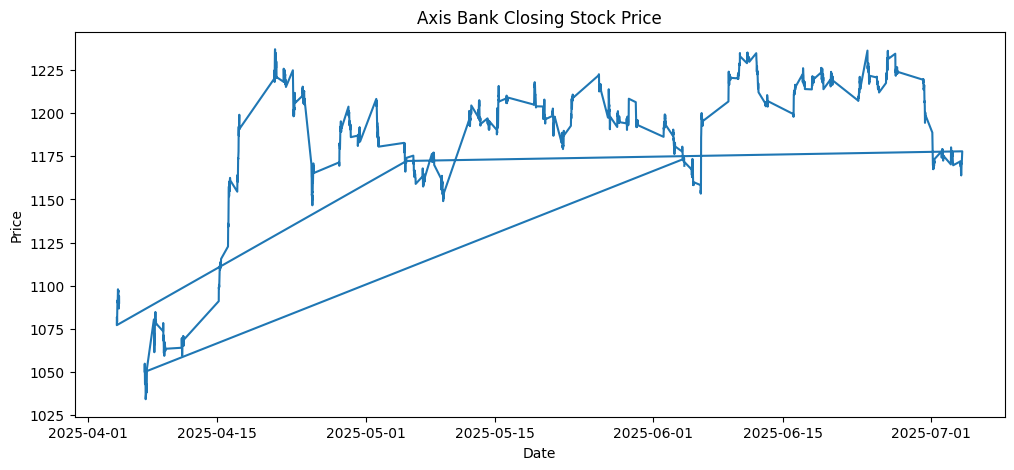

In [7]:
plt.figure(figsize=(12,5))
plt.plot(axisbank['Close'])
plt.title('Axis Bank Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [8]:
def arima_prediction(data, company_name):

    close_prices = data['Close']

    # Train Test Split
    train_size = int(len(close_prices) * 0.8)

    train = close_prices[:train_size]
    test = close_prices[train_size:]

    # ARIMA Model
    model = ARIMA(train, order=(5,1,0))
    model_fit = model.fit()

    # Prediction
    predictions = model_fit.forecast(steps=len(test))

    # RMSE
    rmse = np.sqrt(mean_squared_error(test, predictions))

    print(f'RMSE for {company_name}:', rmse)

    # Plot
    plt.figure(figsize=(12,5))

    plt.plot(test.index, test.values, label='Actual Price')
    plt.plot(test.index, predictions, label='Predicted Price')

    plt.title(f'{company_name} Stock Prediction using ARIMA')

    plt.xlabel('Date')
    plt.ylabel('Stock Price')

    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

RMSE for Axis Bank: 47.86808771709797


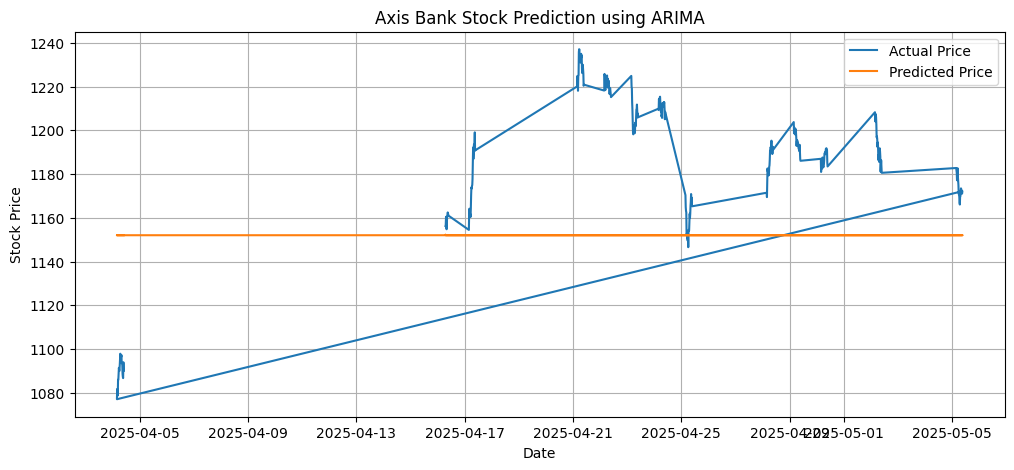

In [9]:
arima_prediction(axisbank, 'Axis Bank')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

RMSE for ICICI Bank: 71.20464190781092


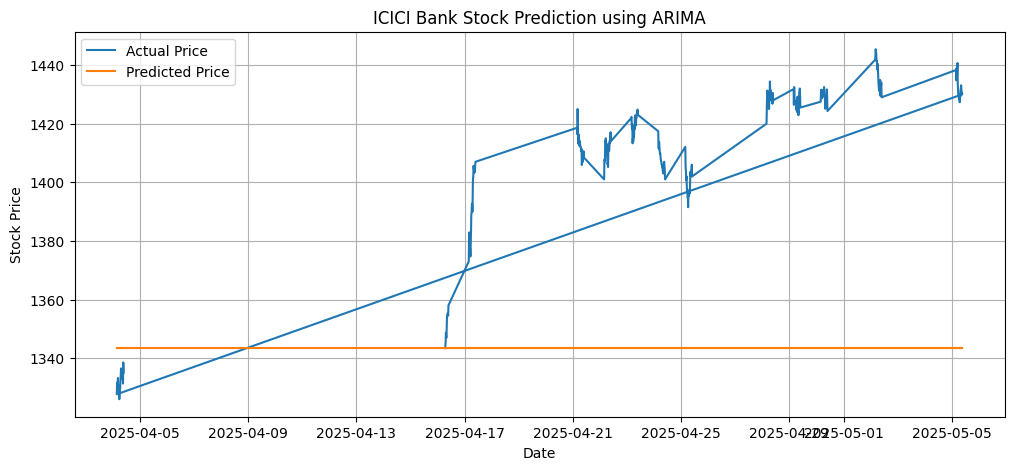

In [10]:
arima_prediction(icicibank, 'ICICI Bank')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

RMSE for HDFC Bank: 62.45599486050669


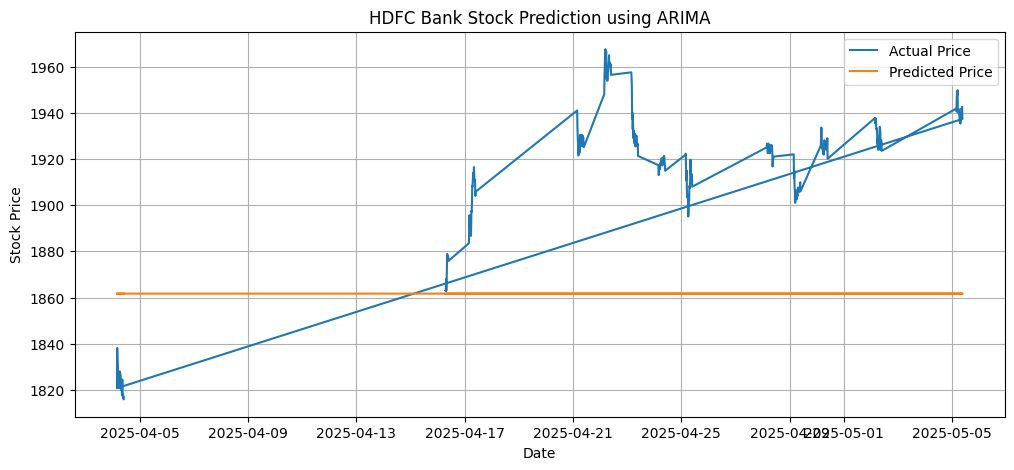

In [11]:
arima_prediction(hdfcbank, 'HDFC Bank')

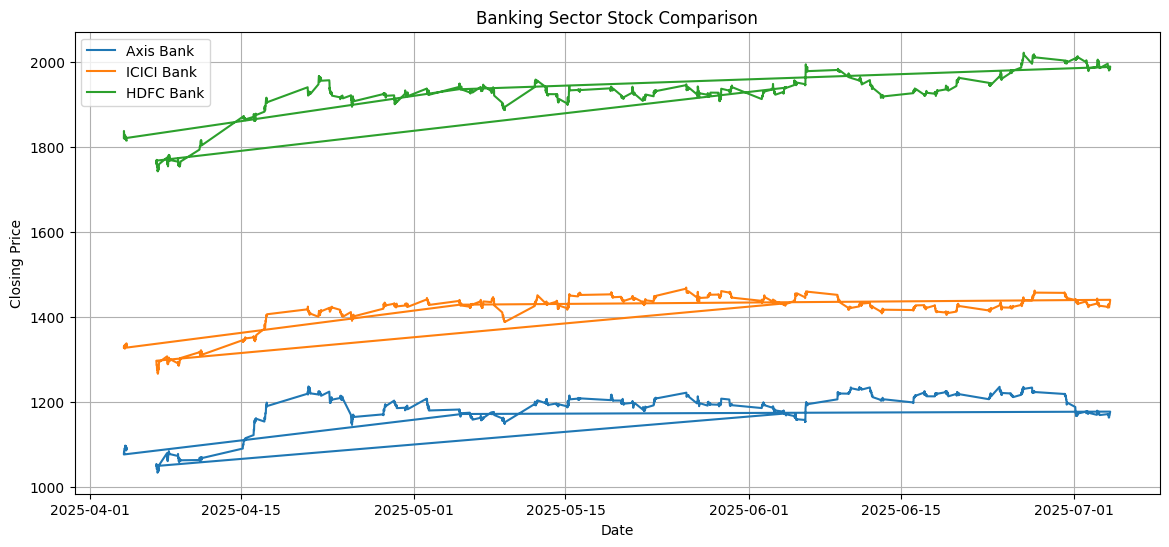

In [12]:
plt.figure(figsize=(14,6))

plt.plot(axisbank['Close'], label='Axis Bank')
plt.plot(icicibank['Close'], label='ICICI Bank')
plt.plot(hdfcbank['Close'], label='HDFC Bank')

plt.title('Banking Sector Stock Comparison')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)
plt.show()